In [6]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import mlflow
import mlflow.lightgbm


In [9]:
data = pd.read_pickle("../data/processed/epias_feature_engineered.pkl")
data.head()

,Tarih,Saat,PTF,SMF,Pozitif Dengesizlik Fiyatı (TL/MWh),Negatif Dengesizlik Fiyatı (TL/MWh),SMF Yön,month,day,season,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_168,Is_Holiday,Is_Weekend,Lag_1,Lag_24,Lag_168
2024-01-14 23:00:00,14.01.2024,23:00,2099.01,1800.00,1746.00,2161.98,Enerji Fazlası,1,Sunday,winter,2217.692083,373.580131,2050.143869,0,1,2245.00,2244.99,129.99
2024-01-15 00:00:00,15.01.2024,00:00,2149.01,1650.12,1600.62,2213.48,Enerji Fazlası,1,Monday,winter,2203.067917,368.889105,2061.298690,0,0,2099.01,2499.99,275.00
2024-01-15 01:00:00,15.01.2024,01:00,1248.99,700.00,679.00,1286.46,Enerji Fazlası,1,Monday,winter,2163.859167,417.186176,2067.959405,0,0,2149.01,2190.00,129.99
2024-01-15 02:00:00,15.01.2024,02:00,1188.88,940.88,912.65,1224.55,Enerji Fazlası,1,Monday,winter,2122.521667,462.145250,2074.351488,0,0,1248.99,2180.98,115.01
2024-01-15 03:00:00,15.01.2024,03:00,1188.88,1183.88,1148.36,1224.55,Enerji Fazlası,1,Monday,winter,2109.558333,484.203502,2080.768274,0,0,1188.88,1500.00,110.86


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16957 entries, 2024-01-14 23:00:00 to 2025-12-20 11:00:00
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   Tarih                                16957 non-null  object  
 1   Saat                                 16957 non-null  object  
 2   PTF                                  16957 non-null  float64 
 3   SMF                                  16957 non-null  float64 
 4   Pozitif Dengesizlik Fiyatı (TL/MWh)  16957 non-null  float64 
 5   Negatif Dengesizlik Fiyatı (TL/MWh)  16957 non-null  float64 
 6   SMF Yön                              16957 non-null  object  
 7   month                                16957 non-null  category
 8   day                                  16957 non-null  category
 9   season                               16957 non-null  category
 10  Rolling_Mean_24                      16957 non-

In [11]:
data['Tarih'] = pd.to_datetime(data['Tarih'], format='%d.%m.%Y')
data['Saat'] = data['Saat'].astype(str).str.split(':').str[0].astype(int)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16957 entries, 2024-01-14 23:00:00 to 2025-12-20 11:00:00
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Tarih                                16957 non-null  datetime64[ns]
 1   Saat                                 16957 non-null  int64         
 2   PTF                                  16957 non-null  float64       
 3   SMF                                  16957 non-null  float64       
 4   Pozitif Dengesizlik Fiyatı (TL/MWh)  16957 non-null  float64       
 5   Negatif Dengesizlik Fiyatı (TL/MWh)  16957 non-null  float64       
 6   SMF Yön                              16957 non-null  object        
 7   month                                16957 non-null  category      
 8   day                                  16957 non-null  category      
 9   season                               16957 non-n

In [13]:
data.head()

,Tarih,Saat,PTF,SMF,Pozitif Dengesizlik Fiyatı (TL/MWh),Negatif Dengesizlik Fiyatı (TL/MWh),SMF Yön,month,day,season,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_168,Is_Holiday,Is_Weekend,Lag_1,Lag_24,Lag_168
2024-01-14 23:00:00,2024-01-14,23,2099.01,1800.00,1746.00,2161.98,Enerji Fazlası,1,Sunday,winter,2217.692083,373.580131,2050.143869,0,1,2245.00,2244.99,129.99
2024-01-15 00:00:00,2024-01-15,0,2149.01,1650.12,1600.62,2213.48,Enerji Fazlası,1,Monday,winter,2203.067917,368.889105,2061.298690,0,0,2099.01,2499.99,275.00
2024-01-15 01:00:00,2024-01-15,1,1248.99,700.00,679.00,1286.46,Enerji Fazlası,1,Monday,winter,2163.859167,417.186176,2067.959405,0,0,2149.01,2190.00,129.99
2024-01-15 02:00:00,2024-01-15,2,1188.88,940.88,912.65,1224.55,Enerji Fazlası,1,Monday,winter,2122.521667,462.145250,2074.351488,0,0,1248.99,2180.98,115.01
2024-01-15 03:00:00,2024-01-15,3,1188.88,1183.88,1148.36,1224.55,Enerji Fazlası,1,Monday,winter,2109.558333,484.203502,2080.768274,0,0,1188.88,1500.00,110.86


In [14]:
# 1. Önce Saati sayısal hale getirdiğimizden emin olalım (Demin yapmıştık ama garanti olsun)
if data['Saat'].dtype.name == 'category':
    # Hesaplama yapabilmek için geçici olarak int yapalım
    data['Saat'] = data['Saat'].astype(int)

# 2. SİNÜS ve KOSİNÜS Dönüşümü (Sihirli Kısım) 🪄
# 2 * pi * saat / 24 formülü saati bir daireye yayar.

# Hour_Sin: Günün dikey döngüsü (Öğlen vs Gece)
data['Hour_Sin'] = np.sin(2 * np.pi * data['Saat'] / 24)

# Hour_Cos: Günün yatay döngüsü (Sabah vs Akşam)
data['Hour_Cos'] = np.cos(2 * np.pi * data['Saat'] / 24)

# 3. Orijinal 'Saat' sütununu ne yapacağız?

data['Saat'] = data['Saat'].astype('category')

print("✅ Saat döngüsel hale getirildi (Sin/Cos eklendi).")
print(data[['Saat', 'Hour_Sin', 'Hour_Cos']].head(24)) # İlk 24 saati gör

✅ Saat döngüsel hale getirildi (Sin/Cos eklendi).
                    Saat      Hour_Sin      Hour_Cos
2024-01-14 23:00:00   23 -2.588190e-01  9.659258e-01
2024-01-15 00:00:00    0  0.000000e+00  1.000000e+00
2024-01-15 01:00:00    1  2.588190e-01  9.659258e-01
2024-01-15 02:00:00    2  5.000000e-01  8.660254e-01
2024-01-15 03:00:00    3  7.071068e-01  7.071068e-01
2024-01-15 04:00:00    4  8.660254e-01  5.000000e-01
2024-01-15 05:00:00    5  9.659258e-01  2.588190e-01
2024-01-15 06:00:00    6  1.000000e+00  6.123234e-17
2024-01-15 07:00:00    7  9.659258e-01 -2.588190e-01
2024-01-15 08:00:00    8  8.660254e-01 -5.000000e-01
2024-01-15 09:00:00    9  7.071068e-01 -7.071068e-01
2024-01-15 10:00:00   10  5.000000e-01 -8.660254e-01
2024-01-15 11:00:00   11  2.588190e-01 -9.659258e-01
2024-01-15 12:00:00   12  1.224647e-16 -1.000000e+00
2024-01-15 13:00:00   13 -2.588190e-01 -9.659258e-01
2024-01-15 14:00:00   14 -5.000000e-01 -8.660254e-01
2024-01-15 15:00:00   15 -7.071068e-01 -7.071068e

In [15]:
data.head()

,Tarih,Saat,PTF,SMF,Pozitif Dengesizlik Fiyatı (TL/MWh),Negatif Dengesizlik Fiyatı (TL/MWh),SMF Yön,month,day,season,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_168,Is_Holiday,Is_Weekend,Lag_1,Lag_24,Lag_168,Hour_Sin,Hour_Cos
2024-01-14 23:00:00,2024-01-14,23,2099.01,1800.00,1746.00,2161.98,Enerji Fazlası,1,Sunday,winter,2217.692083,373.580131,2050.143869,0,1,2245.00,2244.99,129.99,-0.258819,0.965926
2024-01-15 00:00:00,2024-01-15,0,2149.01,1650.12,1600.62,2213.48,Enerji Fazlası,1,Monday,winter,2203.067917,368.889105,2061.298690,0,0,2099.01,2499.99,275.00,0.000000,1.000000
2024-01-15 01:00:00,2024-01-15,1,1248.99,700.00,679.00,1286.46,Enerji Fazlası,1,Monday,winter,2163.859167,417.186176,2067.959405,0,0,2149.01,2190.00,129.99,0.258819,0.965926
2024-01-15 02:00:00,2024-01-15,2,1188.88,940.88,912.65,1224.55,Enerji Fazlası,1,Monday,winter,2122.521667,462.145250,2074.351488,0,0,1248.99,2180.98,115.01,0.500000,0.866025
2024-01-15 03:00:00,2024-01-15,3,1188.88,1183.88,1148.36,1224.55,Enerji Fazlası,1,Monday,winter,2109.558333,484.203502,2080.768274,0,0,1188.88,1500.00,110.86,0.707107,0.707107


ŞİMDİ MODELE GEÇEBİLİRİZ. 

In [21]:

# 2. YASAKLI SÜTUNLAR (Data Leakage)
leakage_cols = [
    'SMF', 
    'Pozitif Dengesizlik Fiyatı (TL/MWh)', 
    'Negatif Dengesizlik Fiyatı (TL/MWh)', 
    'SMF Yön'
]

X = data.drop(columns=leakage_cols + ["PTF","Tarih"])
y = data["PTF"]

# --- KONTROL ---
print(f" X ve y Hazır!")
print(f" Hedef (y): {y.name}")
print(f" Girdiler (X): {X.shape[1]} adet feature kullanılacak.")
print("-" * 30)
print("Kullanılan Feature Listesi (Modelin Gözleri):")
print(X.columns.tolist())

 X ve y Hazır!
 Hedef (y): PTF
 Girdiler (X): 14 adet feature kullanılacak.
------------------------------
Kullanılan Feature Listesi (Modelin Gözleri):
['Saat', 'month', 'day', 'season', 'Rolling_Mean_24', 'Rolling_Std_24', 'Rolling_Mean_168', 'Is_Holiday', 'Is_Weekend', 'Lag_1', 'Lag_24', 'Lag_168', 'Hour_Sin', 'Hour_Cos']


In [22]:
X

,Saat,month,day,season,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_168,Is_Holiday,Is_Weekend,Lag_1,Lag_24,Lag_168,Hour_Sin,Hour_Cos
2024-01-14 23:00:00,23,1,Sunday,winter,2217.692083,373.580131,2050.143869,0,1,2245.00,2244.99,129.99,-0.258819,0.965926
2024-01-15 00:00:00,0,1,Monday,winter,2203.067917,368.889105,2061.298690,0,0,2099.01,2499.99,275.00,0.000000,1.000000
2024-01-15 01:00:00,1,1,Monday,winter,2163.859167,417.186176,2067.959405,0,0,2149.01,2190.00,129.99,0.258819,0.965926
2024-01-15 02:00:00,2,1,Monday,winter,2122.521667,462.145250,2074.351488,0,0,1248.99,2180.98,115.01,0.500000,0.866025
2024-01-15 03:00:00,3,1,Monday,winter,2109.558333,484.203502,2080.768274,0,0,1188.88,1500.00,110.86,0.707107,0.707107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-20 07:00:00,7,12,Saturday,winter,2964.726667,465.340737,2891.769107,0,1,3012.00,3400.00,3117.06,0.965926,-0.258819
2025-12-20 08:00:00,8,12,Saturday,winter,2964.726667,465.340737,2891.769107,0,1,3130.00,3400.00,3400.00,0.866025,-0.500000
2025-12-20 09:00:00,9,12,Saturday,winter,2943.560000,456.143553,2888.932976,0,1,3400.00,3400.00,3368.47,0.707107,-0.707107
2025-12-20 10:00:00,10,12,Saturday,winter,2906.933750,457.460609,2885.319821,0,1,2892.00,3349.02,3077.00,0.500000,-0.866025


In [23]:
y

2024-01-14 23:00:00    2099.01
2024-01-15 00:00:00    2149.01
2024-01-15 01:00:00    1248.99
2024-01-15 02:00:00    1188.88
2024-01-15 03:00:00    1188.88
                        ...   
2025-12-20 07:00:00    3130.00
2025-12-20 08:00:00    3400.00
2025-12-20 09:00:00    2892.00
2025-12-20 10:00:00    2469.99
2025-12-20 11:00:00    2604.99
Name: PTF, Length: 16957, dtype: float64

In [24]:
split_date = '2025-10-01'

# Train 
X_train = X.loc[X.index < split_date]
y_train = y.loc[y.index < split_date]

# Test 
X_test = X.loc[X.index >= split_date]
y_test = y.loc[y.index >= split_date]

print(f" Eğitim Seti: {X_train.shape[0]} saat")
print(f" Test Seti:   {X_test.shape[0]} saat")


 Eğitim Seti: 15025 saat
 Test Seti:   1932 saat


parametreler mlflow'a kaydedildi.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000981 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1626
[LightGBM] [Info] Number of data points in the train set: 15025, number of used features: 14
[LightGBM] [Info] Start training from score 2378.633372


2025/12/22 23:32:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



SONUÇ: MAPE: %31.09 | MAE: 202.79 | RMSE: 309.96 | WMAPE: %7.22 | R2: 0.81



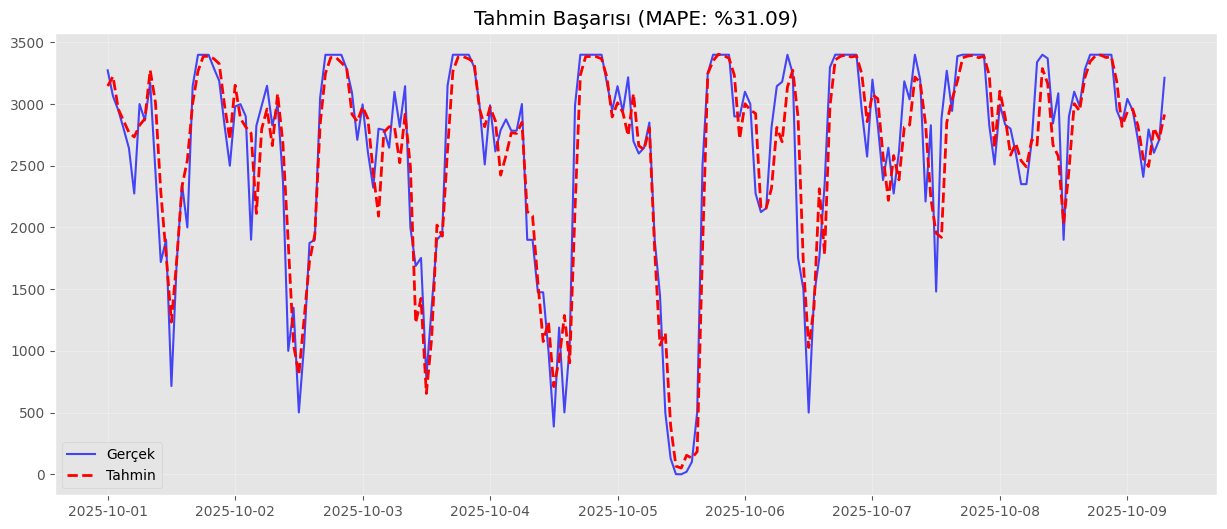

✅ Her şey MLflow'a kaydedildi! (Parametreler, Metrikler, Model, Grafik)


In [33]:
# 1. deney baslatalım

mlflow.set_experiment("ptf-forecasting") 
with mlflow.start_run(run_name="lightgbm_base_model"):
    
    params = {
        'n_estimators': 1000,
        'learning_rate': 0.04,
        'num_leaves': 31,
        'random_state': 44,
        'n_jobs': -1,
        'importance_type': 'gain'
    }
    
    # parametreleri mlflow'a kaydetmek lazımmıs.
    mlflow.log_params(params)
    print("parametreler mlflow'a kaydedildi.")
    
    # Modeli tanımlayalım.
    model = lgb.LGBMRegressor(**params)
    
    callbacks = [lgb.early_stopping(stopping_rounds=50, 
                                    verbose=False)]
    
    # modeli fit edelim.
    model.fit(X_train, y_train,
              eval_set=[(X_train, y_train), (X_test, y_test)],
              eval_metric=["mae", "rmse", "mape","wmape","r2"],
              callbacks=callbacks)
    
    # predict
    y_pred = model.predict(X_test)
    
    mask = y_test != 0
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
    wmape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test) * 100
    r2 = r2_score(y_test, y_pred)
    
    
    # Metrikleri MLflow'a işle (Skorları yazıyoruz)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mape", mape)
    mlflow.log_metric("wmape", wmape)
    mlflow.log_metric("r2", r2)
    
    print(f"\nSONUÇ: MAPE: %{mape:.2f} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | WMAPE: %{wmape:.2f} | R2: {r2:.2f}\n")
    
    # Modeli MLflow'a kaydet
    mlflow.lightgbm.log_model(model, "base_model")
    
    # 1. Tahmin Grafiği
    plt.figure(figsize=(15, 6))
    plt.plot(y_test.index[:200], y_test.values[:200], label='Gerçek', color='blue', alpha=0.7)
    plt.plot(y_test.index[:200], y_pred[:200], label='Tahmin', color='red', linestyle='--', linewidth=2)
    plt.title(f'Tahmin Başarısı (MAPE: %{mape:.2f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Grafiği geçici olarak kaydet ve MLflow'a gönder
    plt.savefig("tahmin_grafigi.png")
    mlflow.log_artifact("tahmin_grafigi.png")
    plt.show() # Yine de ekranda görelim

    print("✅ Her şey MLflow'a kaydedildi! (Parametreler, Metrikler, Model, Grafik)")
    
    
    

mape önemli değil. 
mae : ortalama ne kadar yanıldığımızı gösterir.
rmse: yanılma boyutu önemli ise buna odaklanmamız lazım.

WMAPE (Weighted MAPE)  : ağırlıklı ortalama hata verir. deneyelim. 
r-squared  : 0-1 arası deger alır. 1e yakınlıgı olumlu.

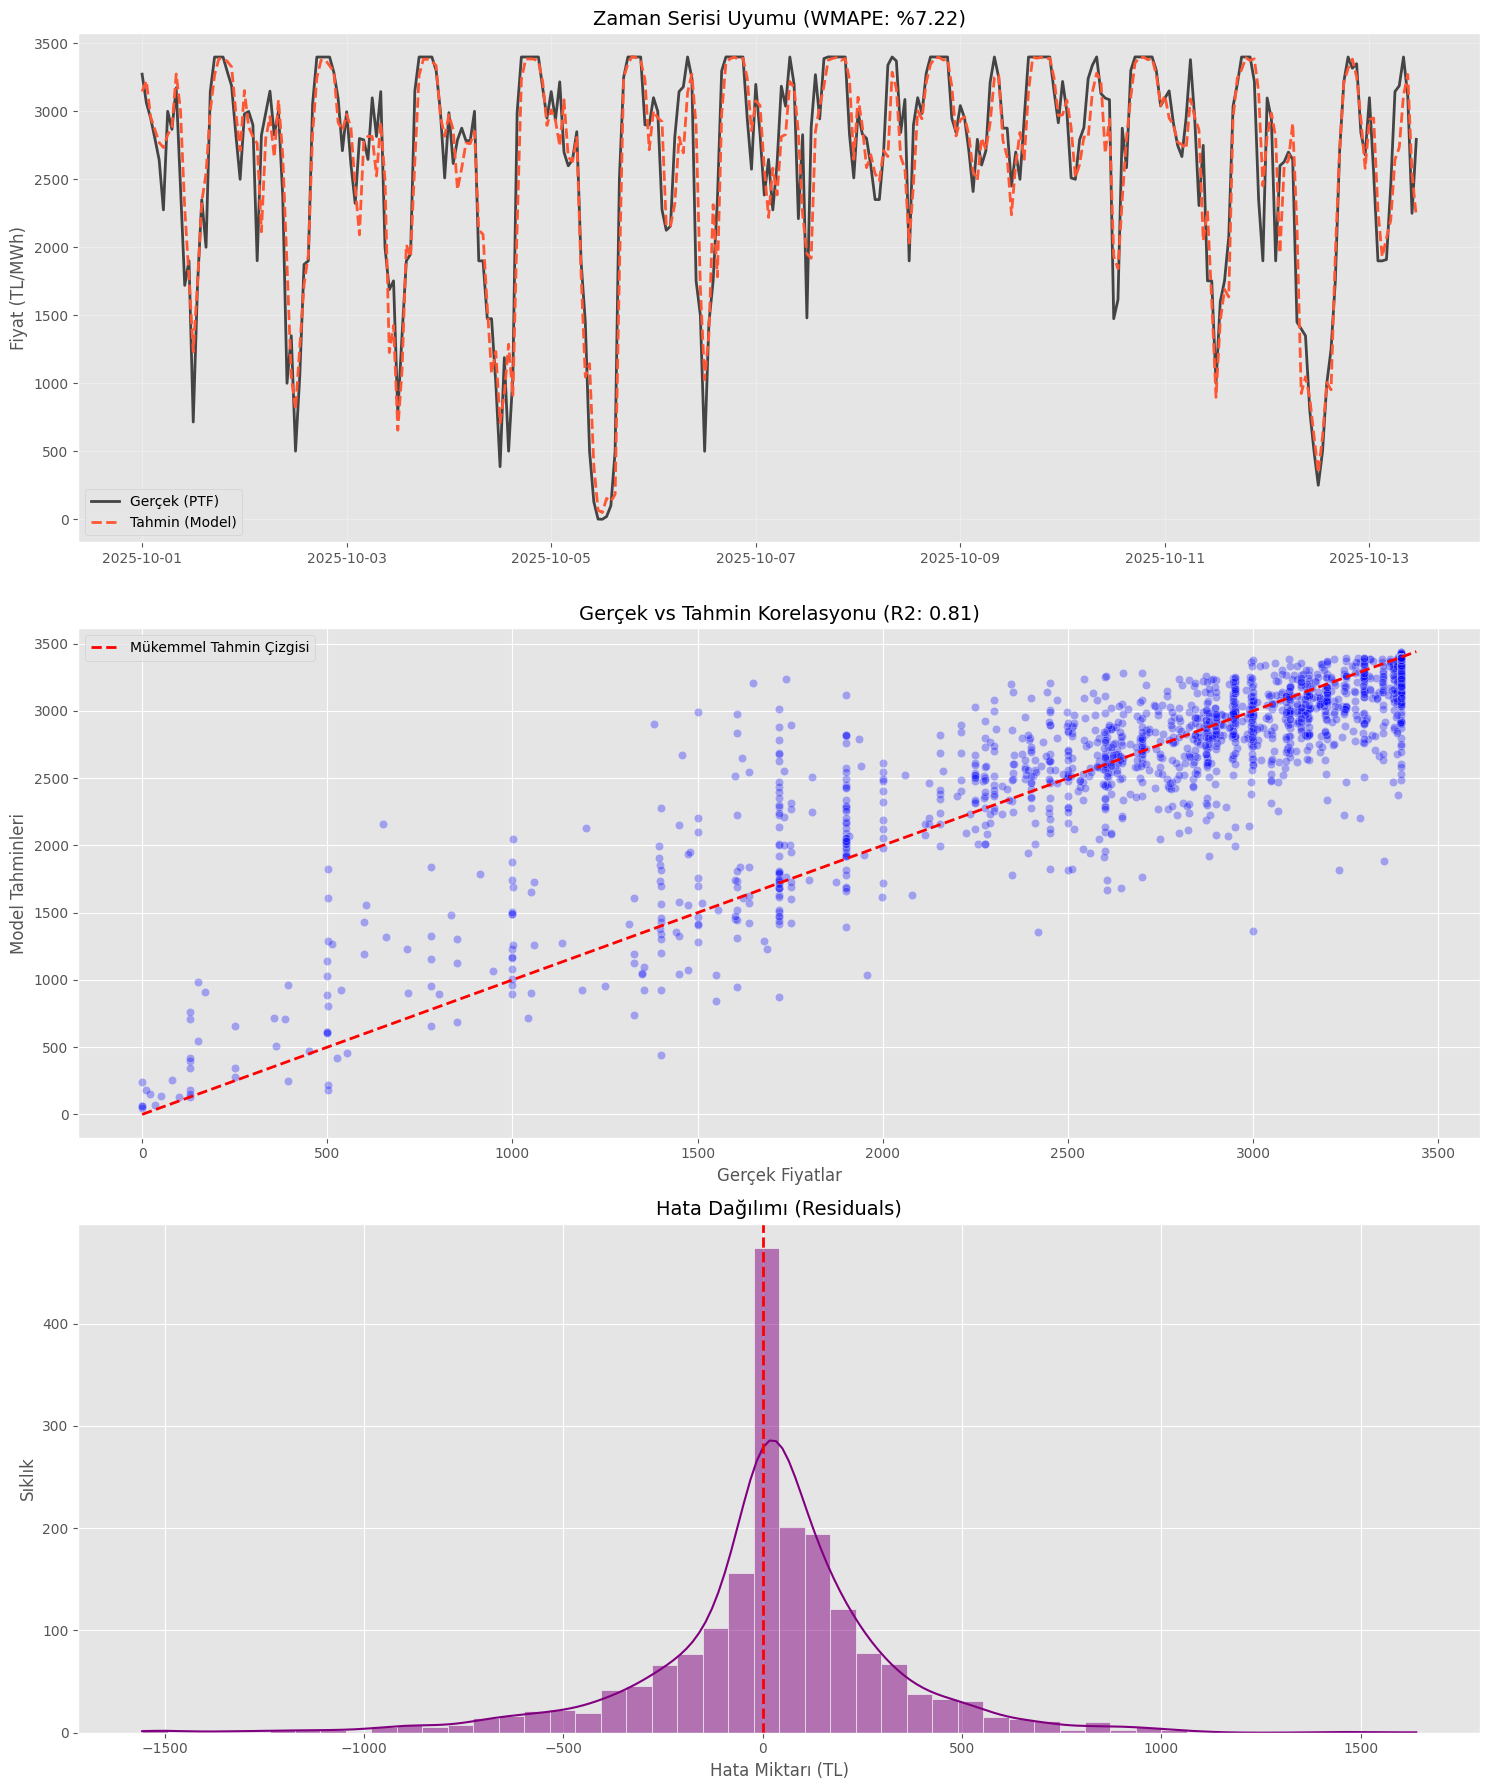

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- GRAFİK AYARLARI ---
plt.style.use('ggplot') # Daha profesyonel görünüm
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# ---------------------------------------------------------
# 1. ZAMAN SERİSİ GRAFİĞİ (Zoom Yapılmış - İlk 300 Saat)
# ---------------------------------------------------------
# Neden 300 saat? Hepsini çizersek çorba olur. Detayı görmek lazım.
axes[0].plot(y_test.index[:300], y_test.values[:300], label='Gerçek (PTF)', color='black', linewidth=2, alpha=0.7)
axes[0].plot(y_test.index[:300], y_pred[:300], label='Tahmin (Model)', color='#FF5733', linestyle='--', linewidth=2)
axes[0].set_title(f'Zaman Serisi Uyumu (WMAPE: %{wmape:.2f})', fontsize=14)
axes[0].set_ylabel('Fiyat (TL/MWh)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---------------------------------------------------------
# 2. SCATTER PLOT (Gerçek vs Tahmin) - R2'nin Resmi
# ---------------------------------------------------------
# İdeal dünyada tüm noktaların kırmızı çizgi (y=x) üzerinde olması gerekir.
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='blue', ax=axes[1])
# Mükemmel uyum çizgisi (Referans)
limits = [0, max(y_test.max(), y_pred.max())]
axes[1].plot(limits, limits, color='red', linestyle='--', linewidth=2, label='Mükemmel Tahmin Çizgisi')
axes[1].set_title(f'Gerçek vs Tahmin Korelasyonu (R2: {r2:.2f})', fontsize=14)
axes[1].set_xlabel('Gerçek Fiyatlar')
axes[1].set_ylabel('Model Tahminleri')
axes[1].legend()

# ---------------------------------------------------------
# 3. RESIDUALS (HATA) DAĞILIMI - Modelin Dürüstlük Testi
# ---------------------------------------------------------
# Hatalar = Gerçek - Tahmin
# Eğer bu grafik "Çan Eğrisi" (Normal Dağılım) şeklindeyse model sağlıklıdır.
residuals = y_test - y_pred
sns.histplot(residuals, bins=50, kde=True, color='purple', ax=axes[2])
axes[2].axvline(0, color='red', linestyle='--', linewidth=2) # 0 noktası
axes[2].set_title('Hata Dağılımı (Residuals)', fontsize=14)
axes[2].set_xlabel('Hata Miktarı (TL)')
axes[2].set_ylabel('Sıklık')

plt.tight_layout()
plt.show()

2. grafiğe bakarsak : model düşük fiyatları iyi tahminleyemediğini(daha yukarıdan tahminleme yapıyor) görüyorum. (2500-3000 arası tahminleme iyi, neden? arastıralım)


3. grafiği yorumlayalım : bias yok, dengeli prediction. 
hataların büyük kısmı -/+500 bandında : bu günlük saatlerde isabetli prediction yaptıgı anlamına gelir.
kuyruklar : nadir büyük hatalar var : şok saaatler, ani fiyat çöküşleri vs (rmse,mape hatası)

------------------------------------------------ BASE MODEL ANALYZE ---------------------------------------------------------

In [30]:
# 1. Hem Train hem Test için tahmin yap
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# 2. İkisinin de WMAPE skorunu hesapla (Adil karşılaştırma)
def calculate_wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

train_wmape = calculate_wmape(y_train, y_pred_train)
test_wmape = calculate_wmape(y_test, y_pred_test)

print(f"📘 Eğitim (Train) Hatası : %{train_wmape:.2f}")
print(f"📝 Test (Sınav) Hatası    : %{test_wmape:.2f}")

# 3. Farkı Yorumla
gap = test_wmape - train_wmape
print(f"🔻 Fark (Gap)             : %{gap:.2f}")

if gap > 5:
    print("⚠️ UYARI: Ciddi Overfitting riski var! (Fark %5'ten büyük)")
elif gap > 2:
    print("🤔 DİKKAT: Hafif ezberleme var, ama kabul edilebilir.")
else:
    print("✅ MÜKEMMEL: Model ezberlememiş, gerçekten öğrenmiş.")

📘 Eğitim (Train) Hatası : %6.26
📝 Test (Sınav) Hatası    : %7.22
🔻 Fark (Gap)             : %0.96
✅ MÜKEMMEL: Model ezberlememiş, gerçekten öğrenmiş.


In [ ]:
print("Eğitim seti metrik isimleri:", model.evals_result_['training'].keys())

Eğitim seti metrik isimleri: odict_keys(['l1', 'rmse', 'mape', 'l2'])


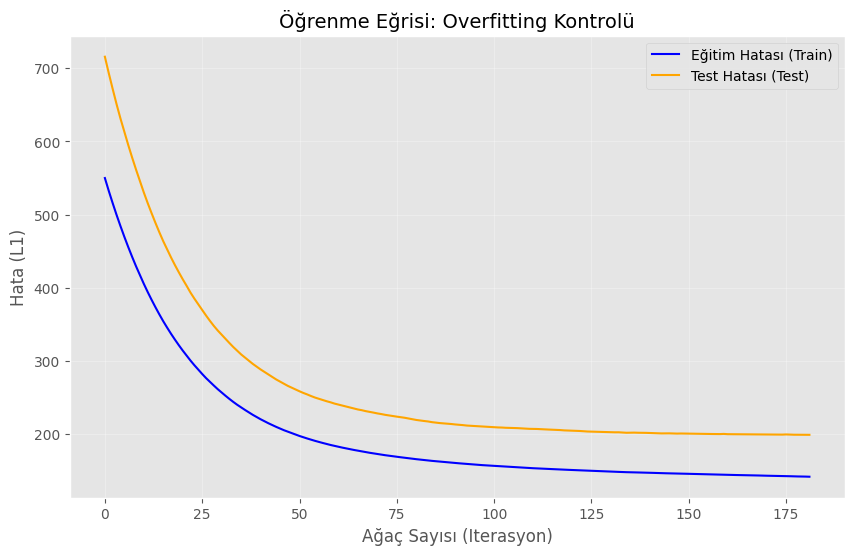

In [36]:
# Modelin içindeki kayıtlı sonuçları alalım
results = model.evals_result_

plt.figure(figsize=(10, 6))
plt.plot(results['training']['l1'], label='Eğitim Hatası (Train)', color='blue')
plt.plot(results['valid_1']['l1'], label='Test Hatası (Test)', color='orange')
plt.title('Öğrenme Eğrisi: Overfitting Kontrolü', fontsize=14)
plt.xlabel('Ağaç Sayısı (Iterasyon)')
plt.ylabel('Hata (L1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

grafik temiz overfit yok , 80-120 ağaç sonrasının öğrenmeye katkısı yok. Ne yapabiliriz araştıralım. 

C:\Users\90546\AppData\Local\Temp\ipykernel_23432\3036435597.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Feature", data=feature_imp, palette="viridis")


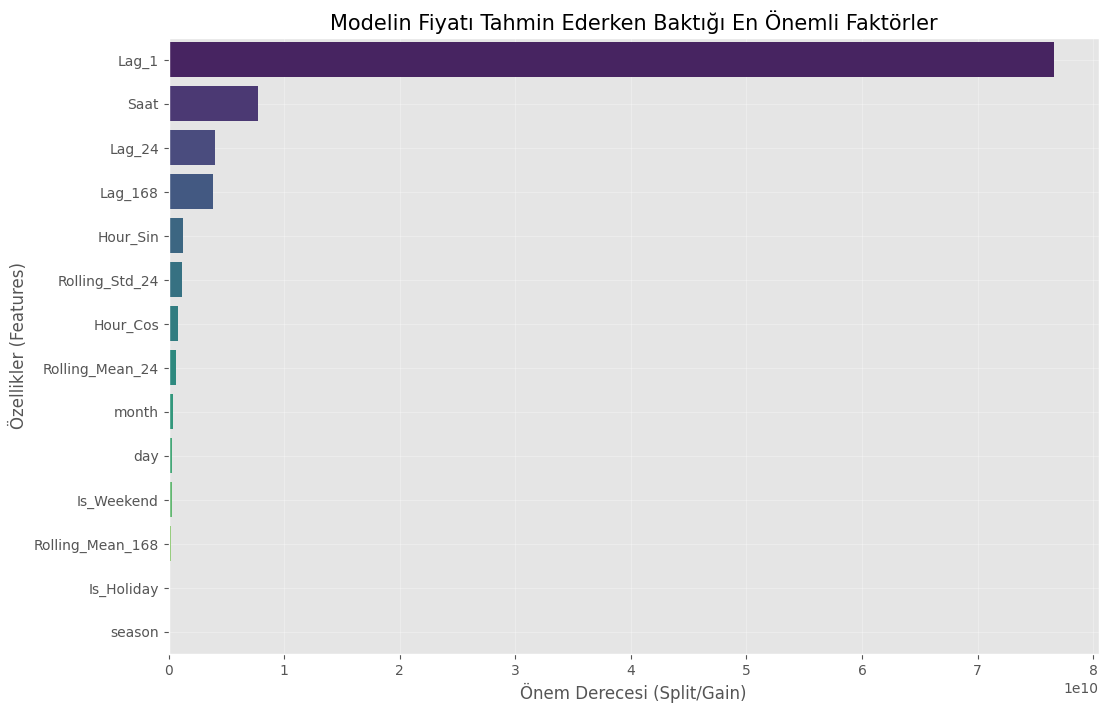

🏆 EN ÖNEMLİ 5 ÖZELLİK:
           Value   Feature
13  7.663876e+10     Lag_1
12  7.718852e+09      Saat
11  4.032863e+09    Lag_24
10  3.812137e+09   Lag_168
9   1.206709e+09  Hour_Sin


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- FEATURE IMPORTANCE (ÖZELLİK ÖNEM DÜZEYİ) ---

# 1. Modelden önem derecelerini al
feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X_train.columns)), columns=['Value','Feature'])

# 2. En önemliden en aza doğru sırala
feature_imp = feature_imp.sort_values(by="Value", ascending=False)

# 3. Grafik Çiz (Bar Plot)
plt.figure(figsize=(12, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp, palette="viridis")
plt.title('Modelin Fiyatı Tahmin Ederken Baktığı En Önemli Faktörler', fontsize=15)
plt.xlabel('Önem Derecesi (Split/Gain)', fontsize=12)
plt.ylabel('Özellikler (Features)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 4. İlk 5'i yazdır
print("🏆 EN ÖNEMLİ 5 ÖZELLİK:")
print(feature_imp.head(5))

------------------------------------------- HİPERPARAMETRE OPTİMİZASYONU -------------------------------------------------------

In [39]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
pip install optuna-integration

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import optuna
import mlflow
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from optuna.integration import LightGBMPruningCallback

# 1. DENEY ADI
mlflow.set_experiment("hyperparameter_optimization_full_metrics")

# 2. AMAÇ FONKSİYONU
def objective(trial):
    
    # --- A. Parametre Uzayı ---
    param = {
        'objective': 'regression',
        'metric': 'mae', # Model eğitimi sırasında bunu takip etsin
        'verbosity': -1,
        'n_jobs': -1,
        'random_state': 44,
        
        # Optuna'nın oynayacağı ayarlar:
        'n_estimators': trial.suggest_int('n_estimators', 1000, 4000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', -1, 20),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    # --- B. MLflow Kaydı ---
    with mlflow.start_run(nested=True):
        
        # Eğit
        model = lgb.LGBMRegressor(**param)
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            eval_metric='mae',
            callbacks=[LightGBMPruningCallback(trial, "l1")]
        )
        
        # Tahmin Et
        preds = model.predict(X_test)
        
        # --- C. TÜM METRİKLERİ HESAPLA (Senin İstediğin Kısım) ---
        
        # 1. MAE
        mae = mean_absolute_error(y_test, preds)
        
        # 2. RMSE
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        
        # 3. R2 (Başarı Puanı)
        r2 = r2_score(y_test, preds)
        
        # 4. WMAPE (Ticari Kral)
        wmape = np.sum(np.abs(y_test - preds)) / np.sum(y_test) * 100
        
        # 5. MAPE (Senin şu %31 çıkan, ama yine de görmek istediğin)
        # Sıfıra bölme hatası olmasın diye maskeleme yapıyoruz
        mask = y_test != 0
        mape = np.mean(np.abs((y_test[mask] - preds[mask]) / y_test[mask])) * 100
        
        # --- D. MLflow'a Hepsini İşle ---
        mlflow.log_params(param) # Parametreleri kaydet
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2", r2)
        mlflow.log_metric("wmape", wmape)
        mlflow.log_metric("mape", mape)
        
        # --- E. Ekrana Canlı Yazdır ---
        print(f"Trial {trial.number} Bitti -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | WMAPE: %{wmape:.2f} | R2: {r2:.3f}")
        
        # Optuna'ya sadece MAE'yi dönüyoruz (Onu minimize etmeye çalışsın)
        return mae

# 3. BAŞLAT
print("🧠 Optuna Full Metrik Modunda Çalışıyor...")
study = optuna.create_study(direction='minimize', study_name="Full_Metrics_Optim")
study.optimize(objective, n_trials=20) # 20 deneme yapacak

print("\n🏆 ŞAMPİYON PARAMETRELER:")
print(study.best_params)
print(f"En İyi MAE: {study.best_value}")

2025/12/23 00:00:40 INFO mlflow.tracking.fluent: Experiment with name 'hyperparameter_optimization_full_metrics' does not exist. Creating a new experiment.


[I 2025-12-23 00:00:40,168] A new study created in memory with name: Full_Metrics_Optim


🧠 Optuna Full Metrik Modunda Çalışıyor...


[I 2025-12-23 00:00:48,685] Trial 0 finished with value: 207.84596101501427 and parameters: {'n_estimators': 2639, 'learning_rate': 0.013340728850556979, 'num_leaves': 93, 'max_depth': 0, 'colsample_bytree': 0.7318938187463524, 'subsample': 0.8009112403008384, 'min_child_samples': 83, 'reg_alpha': 2.0838231647494463, 'reg_lambda': 5.770207389414517}. Best is trial 0 with value: 207.84596101501427.


Trial 0 Bitti -> MAE: 207.85 | RMSE: 305.03 | WMAPE: %7.40 | R2: 0.820


...

Trial 16 Bitti -> MAE: 214.88 | RMSE: 307.97 | WMAPE: %7.65 | R2: 0.817


[I 2025-12-23 00:01:25,505] Trial 18 finished with value: 208.15107815517172 and parameters: {'n_estimators': 2845, 'learning_rate': 0.04759111986326351, 'num_leaves': 58, 'max_depth': 3, 'colsample_bytree': 0.8210946011537283, 'subsample': 0.7758565250862569, 'min_child_samples': 62, 'reg_alpha': 0.00015405199590940417, 'reg_lambda': 0.6129396049221512}. Best is trial 2 with value: 205.26540873962492.


Trial 18 Bitti -> MAE: 208.15 | RMSE: 304.94 | WMAPE: %7.41 | R2: 0.820


[I 2025-12-23 00:01:25,675] Trial 19 pruned. Trial was pruned at iteration 0.



🏆 ŞAMPİYON PARAMETRELER:
{'n_estimators': 1494, 'learning_rate': 0.006198062756878811, 'num_leaves': 148, 'max_depth': 19, 'colsample_bytree': 0.46794174773509917, 'subsample': 0.9793443043824566, 'min_child_samples': 61, 'reg_alpha': 5.324383037093246, 'reg_lambda': 1.2623291037329564e-05}
En İyi MAE: 205.26540873962492


🥇 Optuna'dan gelen en iyi parametreler alınıyor...
⚙️ Final Parametreler: {'n_estimators': 1494, 'learning_rate': 0.006198062756878811, 'num_leaves': 148, 'max_depth': 19, 'colsample_bytree': 0.46794174773509917, 'subsample': 0.9793443043824566, 'min_child_samples': 61, 'reg_alpha': 5.324383037093246, 'reg_lambda': 1.2623291037329564e-05, 'objective': 'regression', 'metric': 'mae', 'verbosity': -1, 'n_jobs': -1, 'random_state': 44}

🚀 Final Model Eğitiliyor...

📊 Sonuçlar Hesaplanıyor...
----------------------------------------
🏆 --- FİNAL OPTİMİZE SONUÇLAR ---
----------------------------------------
✅ WMAPE (Ticari Başarı) : %7.31
✅ R2 Score (Uyum)       : 0.8202
✅ MAE (Ortalama Hata)   : 205.33 TL
✅ RMSE (Risk Göstergesi) : 305.17 TL
----------------------------------------


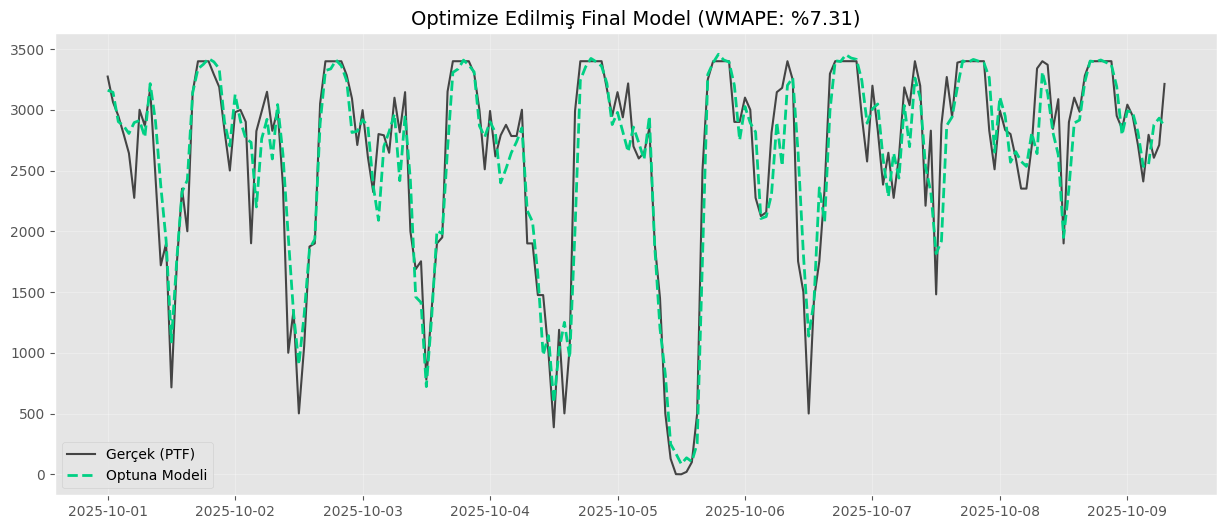

In [43]:
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- 1. ŞAMPİYON PARAMETRELERİ HAZIRLA 🏆 ---
print("🥇 Optuna'dan gelen en iyi parametreler alınıyor...")

# Optuna'nın bulduğu değişken ayarlar
final_params = study.best_params

# Optuna'nın dokunmadığı sabit ayarları da ekleyelim (Yoksa eksik kalır!)
fixed_params = {
    'objective': 'regression',
    'metric': 'mae',
    'verbosity': -1,
    'n_jobs': -1,
    'random_state': 44
}

# İkisini birleştiriyoruz (Altın Reçete + Sabitler)
final_params.update(fixed_params)

print(f"⚙️ Final Parametreler: {final_params}")

# --- 2. ŞAMPİYON MODELİ EĞİT 🏋️‍♂️ ---
print("\n🚀 Final Model Eğitiliyor...")

best_model = lgb.LGBMRegressor(**final_params)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# --- 3. TAHMİN YAP VE KARNEYİ ÇIKAR 📝 ---
print("\n📊 Sonuçlar Hesaplanıyor...")
y_pred_final = best_model.predict(X_test)

# Metrikler
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)
wmape = np.sum(np.abs(y_test - y_pred_final)) / np.sum(y_test) * 100

# Ekrana Yazdır
print("-" * 40)
print(f"🏆 --- FİNAL OPTİMİZE SONUÇLAR ---")
print("-" * 40)
print(f"✅ WMAPE (Ticari Başarı) : %{wmape:.2f}")
print(f"✅ R2 Score (Uyum)       : {r2:.4f}")
print(f"✅ MAE (Ortalama Hata)   : {mae:.2f} TL")
print(f"✅ RMSE (Risk Göstergesi) : {rmse:.2f} TL")
print("-" * 40)

# --- 4. GÖRSEL ŞÖLEN (GRAFİK) 🎨 ---
plt.figure(figsize=(15, 6))
# İlk 200 saati çizdirelim ki detay görünsün
plt.plot(y_test.index[:200], y_test.values[:200], label='Gerçek (PTF)', color='black', alpha=0.7)
plt.plot(y_test.index[:200], y_pred_final[:200], label='Optuna Modeli', color='#00d084', linestyle='--', linewidth=2)

plt.title(f'Optimize Edilmiş Final Model (WMAPE: %{wmape:.2f})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
import optuna
import mlflow
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error
from optuna.integration import LightGBMPruningCallback

mlflow.set_experiment("hyperparameter_optimization_v2")

def objective(trial):
    param = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'n_jobs': -1,
        'random_state': 44,
        
        # --- STRATEJİ DEĞİŞİKLİĞİ: DAHA DAR ARALIKLAR ---
        
        # Base model 31 idi, biz 20-60 arasına bakalım (150 çok fazlaydı)
        'num_leaves': trial.suggest_int('num_leaves', 20, 60),
        
        # Derinlik çok artmasın, overfit yapar
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        
        # Öğrenme hızı: Çok yavaş olmasın ama çok hızlı da olmasın
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        
        # Ağaç sayısı: 1000 az gelebilir, 3000 çok olabilir
        'n_estimators': trial.suggest_int('n_estimators', 1500, 3500),
        
        # Genelleştirme ayarları
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        
        # Minik yaprakları engelle (Gürültüyü öğrenmesin)
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
    }

    # Model Eğitimi
    with mlflow.start_run(nested=True):
        model = lgb.LGBMRegressor(**param)
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            eval_metric='mae',
            callbacks=[LightGBMPruningCallback(trial, "l1")]
        )
        
        preds = model.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        mlflow.log_params(param)
        mlflow.log_metric("mae", mae)
        
        return mae

print("🧠 Optuna V2: Daha akıllı ve odaklı arama başlıyor...")
study = optuna.create_study(direction='minimize', study_name="Conservative_Optim")

# DENEME SAYISINI ARTIRDIK: 50
study.optimize(objective, n_trials=50) 

print("\n🏆 YENİ ŞAMPİYON ADAYLARI:")
print(study.best_params)
print(f"En İyi MAE: {study.best_value}")

2025/12/23 00:13:53 INFO mlflow.tracking.fluent: Experiment with name 'hyperparameter_optimization_v2' does not exist. Creating a new experiment.
[I 2025-12-23 00:13:53,783] A new study created in memory with name: Conservative_Optim


🧠 Optuna V2: Daha akıllı ve odaklı arama başlıyor...


[I 2025-12-23 00:13:59,763] Trial 0 finished with value: 207.54444884679486 and parameters: {'num_leaves': 57, 'max_depth': 9, 'learning_rate': 0.01944676524417427, 'n_estimators': 3078, 'colsample_bytree': 0.6547428991007869, 'subsample': 0.8431762259168507, 'min_child_samples': 47}. Best is trial 0 with value: 207.54444884679486.
[I 2025-12-23 00:14:02,594] Trial 1 finished with value: 201.5145987195138 and parameters: {'num_leaves': 42, 'max_depth': 9, 'learning_rate': 0.011265609864952359, 'n_estimators': 1771, 'colsample_bytree': 0.7655379523115077, 'subsample': 0.6291441593131105, 'min_child_samples': 94}. Best is trial 1 with value: 201.5145987195138.
[I 2025-12-23 00:14:05,157] Trial 2 finished with value: 208.05352779973921 and parameters: {'num_leaves': 31, 'max_depth': 7, 'learning_rate': 0.028309690561311045, 'n_estimators': 2050, 'colsample_bytree': 0.859205463647429, 'subsample': 0.6673613569455621, 'min_child_samples': 20}. Best is trial 1 with value: 201.5145987195138.



🏆 YENİ ŞAMPİYON ADAYLARI:
{'num_leaves': 42, 'max_depth': 9, 'learning_rate': 0.011265609864952359, 'n_estimators': 1771, 'colsample_bytree': 0.7655379523115077, 'subsample': 0.6291441593131105, 'min_child_samples': 94}
En İyi MAE: 201.5145987195138


🥇 Optuna V2'den (Conservative) gelen en iyi parametreler alınıyor...
⚙️ Final Parametreler: {'num_leaves': 35, 'max_depth': 7, 'learning_rate': 0.014501053665156262, 'n_estimators': 2014, 'colsample_bytree': 0.6244131447296348, 'subsample': 0.7042668159422949, 'min_child_samples': 25, 'objective': 'regression', 'metric': 'mae', 'verbosity': -1, 'n_jobs': -1, 'random_state': 44}

🚀 Final Model Eğitiliyor...

📊 Sonuçlar Hesaplanıyor...
--------------------------------------------------
🏆 --- FİNAL SONUÇLAR (OPTUNA V2) ---
--------------------------------------------------
✅ WMAPE (Ticari Başarı) : %6.99  (Base: %7.22)
✅ MAE (Ortalama Hata)   : 196.37 TL (Base: 202.79 TL)
✅ RMSE (Risk)           : 297.80 TL
✅ R2 Score (Uyum)       : 0.8288
--------------------------------------------------
🎉 TEBRİKLER! Base Modeli geçmeyi başardık!
İyileşme: %0.23 puan


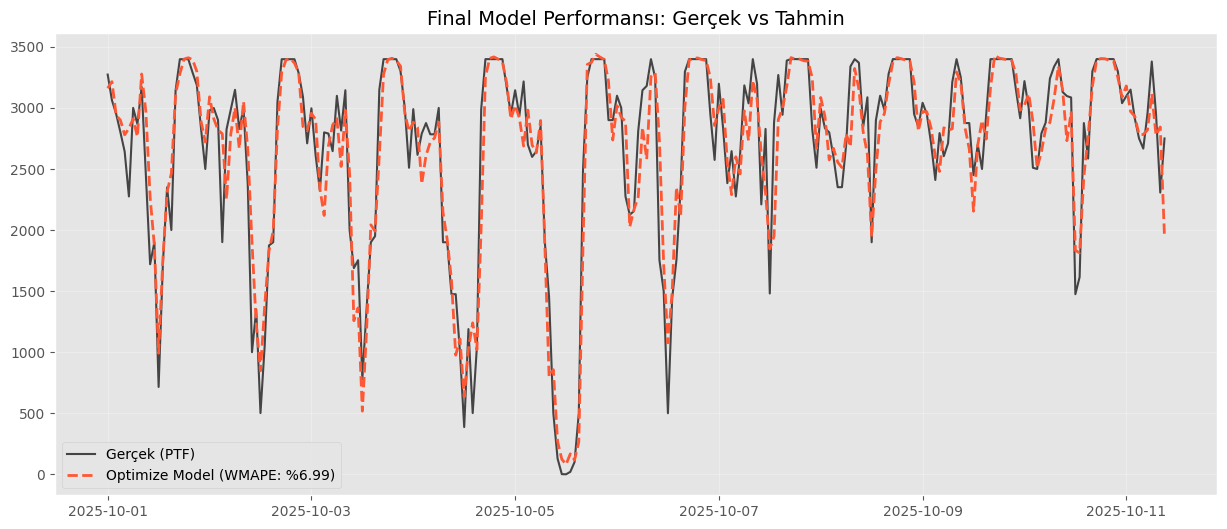

In [45]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- 1. ŞAMPİYON PARAMETRELERİ HAZIRLA 🏆 ---
print("🥇 Optuna V2'den (Conservative) gelen en iyi parametreler alınıyor...")

# Optuna'nın bulduğu değişken ayarlar
final_params = study.best_params

# Optuna'nın dokunmadığı sabit ayarları ekle
fixed_params = {
    'objective': 'regression',
    'metric': 'mae',
    'verbosity': -1,
    'n_jobs': -1,
    'random_state': 44
}

# Hepsini birleştir
final_params.update(fixed_params)

print(f"⚙️ Final Parametreler: {final_params}")

# --- 2. FİNAL MODELİ EĞİT 🏋️‍♂️ ---
print("\n🚀 Final Model Eğitiliyor...")

final_model = lgb.LGBMRegressor(**final_params)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# --- 3. METRİKLERİ HESAPLA 📝 ---
print("\n📊 Sonuçlar Hesaplanıyor...")
y_pred_final = final_model.predict(X_test)

# Metrik Hesaplamaları
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)
wmape = np.sum(np.abs(y_test - y_pred_final)) / np.sum(y_test) * 100

# Base Model Referansı (Karşılaştırma için)
base_mae = 202.79
base_wmape = 7.22

# --- 4. KARNEYİ YAZDIR 📢 ---
print("-" * 50)
print(f"🏆 --- FİNAL SONUÇLAR (OPTUNA V2) ---")
print("-" * 50)
print(f"✅ WMAPE (Ticari Başarı) : %{wmape:.2f}  (Base: %{base_wmape})")
print(f"✅ MAE (Ortalama Hata)   : {mae:.2f} TL (Base: {base_mae} TL)")
print(f"✅ RMSE (Risk)           : {rmse:.2f} TL")
print(f"✅ R2 Score (Uyum)       : {r2:.4f}")
print("-" * 50)

# Yorumlayıcı
if wmape < base_wmape:
    print("🎉 TEBRİKLER! Base Modeli geçmeyi başardık!")
    print(f"İyileşme: %{base_wmape - wmape:.2f} puan")
elif wmape == base_wmape:
    print("🤝 BERABERE. Optimizasyon aynı sonucu verdi.")
else:
    print("🛡️ BASE MODEL HALA KRAL. Karmaşık ayarlar işe yaramadı.")
    print("Basitlik (Base Model) kazandı.")

# --- 5. GRAFİK (Zaman Serisi) 🎨 ---
plt.figure(figsize=(15, 6))
# İlk 250 saati çizdirelim
plt.plot(y_test.index[:250], y_test.values[:250], label='Gerçek (PTF)', color='black', alpha=0.7)
plt.plot(y_test.index[:250], y_pred_final[:250], label=f'Optimize Model (WMAPE: %{wmape:.2f})', color='#FF5733', linestyle='--', linewidth=2)

plt.title(f'Final Model Performansı: Gerçek vs Tahmin', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()